In [2]:
import tensorflow as tf
from tensorflow.keras import layers, models
import matplotlib.pyplot as plt
import numpy as np

In [5]:
mnist = tf.keras.datasets.mnist

In [6]:
(X_train, y_train), (X_test, y_test) = mnist.load_data()

In [7]:
X_train = X_train / 255.0
X_test = X_test / 255.0

In [8]:
X_train = X_train.reshape(-1, 28, 28, 1)
X_test = X_test.reshape(-1, 28, 28, 1)

In [9]:
print(f"Training data shape: {X_train.shape}")
print(f"Test data shape: {X_test.shape}")

Training data shape: (60000, 28, 28, 1)
Test data shape: (10000, 28, 28, 1)


In [10]:
model = models.Sequential([
    # First Convolutional Layer: Learns 32 low-level features (edges/lines)
    layers.Conv2D(32, (3, 3), activation='relu', input_shape=(28, 28, 1)),
    layers.MaxPooling2D((2, 2)), # Reduces spatial dimensions by half
    
    # Second Convolutional Layer: Learns 64 higher-level features (shapes/curves)
    layers.Conv2D(64, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),
    
    # Flattening the 2D matrices into a 1D vector for the Dense layers
    layers.Flatten(),
    
    # Fully Connected (Dense) Layers
    layers.Dense(64, activation='relu'),
    layers.Dropout(0.2), # Randomly drops 20% of neurons to prevent overfitting
    
    # Output Layer: 10 neurons corresponding to classes 0 through 9
    layers.Dense(10, activation='softmax')
])

C:\Users\dkkam\anaconda3\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [11]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                      │ (None, 26, 26, 32)          │             320 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d (MaxPooling2D)         │ (None, 13, 13, 32)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_1 (Conv2D)                    │ (None, 11, 11, 64)          │          18,496 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_1 (MaxPooling2D)       │ (None, 5, 5, 64)            │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ flatten (Flatten)                    │ (None, 1600)                │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 64)                  │         102,464 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout (Dropout)                    │ (None, 64)                  │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 10)                  │             650 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 121,930 (476.29 KB)

 Trainable params: 121,930 (476.29 KB)

 Non-trainable params: 0 (0.00 B)

In [12]:
# 3. COMPILE THE MODEL
model.compile(optimizer='adam',
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

In [13]:
# 4. TRAIN THE MODEL
print("\n--- Training the CNN ---")
history = model.fit(X_train, y_train, epochs=5, batch_size=64, validation_split=0.1)


--- Training the CNN ---
Epoch 1/5
844/844 ━━━━━━━━━━━━━━━━━━━━ 45s 47ms/step - accuracy: 0.9308 - loss: 0.2272 - val_accuracy: 0.9855 - val_loss: 0.0494
Epoch 2/5
844/844 ━━━━━━━━━━━━━━━━━━━━ 38s 45ms/step - accuracy: 0.9788 - loss: 0.0711 - val_accuracy: 0.9895 - val_loss: 0.0409
Epoch 3/5
844/844 ━━━━━━━━━━━━━━━━━━━━ 42s 46ms/step - accuracy: 0.9840 - loss: 0.0527 - val_accuracy: 0.9903 - val_loss: 0.0369
Epoch 4/5
844/844 ━━━━━━━━━━━━━━━━━━━━ 45s 51ms/step - accuracy: 0.9871 - loss: 0.0416 - val_accuracy: 0.9898 - val_loss: 0.0344
Epoch 5/5
844/844 ━━━━━━━━━━━━━━━━━━━━ 80s 49ms/step - accuracy: 0.9888 - loss: 0.0340 - val_accuracy: 0.9898 - val_loss: 0.0346


In [14]:
print("\n--- Evaluating Model Accuracy ---")
test_loss, test_acc = model.evaluate(X_test, y_test, verbose=2)
print(f"\nTest Accuracy: {test_acc * 100:.2f}%")


--- Evaluating Model Accuracy ---
313/313 - 5s - 16ms/step - accuracy: 0.9891 - loss: 0.0349

Test Accuracy: 98.91%


In [15]:
predictions = model.predict(X_test)

313/313 ━━━━━━━━━━━━━━━━━━━━ 5s 15ms/step


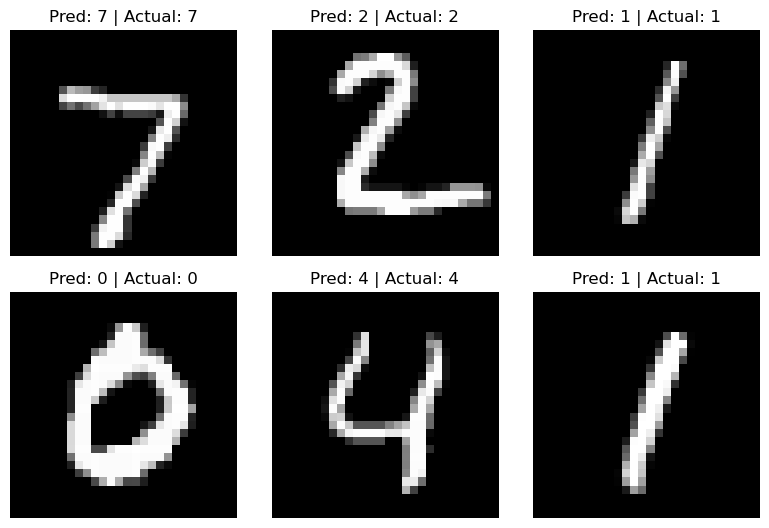

In [28]:
# Plot a few test images alongside their predicted labels
plt.figure(figsize=(8, 8))
for i in range(6):
    plt.subplot(3, 3, i + 1)
    plt.imshow(X_test[i].reshape(28, 28), cmap='gray')
    predicted_label = np.argmax(predictions[i])
    actual_label = y_test[i]
    plt.title(f"Pred: {predicted_label} | Actual: {actual_label}")
    plt.axis('off')
plt.tight_layout()
plt.show()